In [2]:
# CELL 1 — Install Libraries
# ──────────────────────────────────────────────────────────────
import subprocess, sys
for pkg in ['scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True)
print("✅ All packages ready")

✅ All packages ready


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      StratifiedKFold)
from sklearn.metrics import (roc_curve, auc, classification_report,
                              confusion_matrix, recall_score)
from sklearn.pipeline import Pipeline

np.random.seed(42)
%matplotlib inline

plt.rcParams.update({
    'figure.facecolor' : '#0d1117',
    'axes.facecolor'   : '#161b22',
    'text.color'       : 'white',
    'axes.labelcolor'  : '#cdd9e5',
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.edgecolor'   : '#30363d',
    'grid.color'       : '#21262d',
    'figure.dpi'       : 110,
})

import sklearn
print("✅ All libraries imported")
print(f"   scikit-learn : {sklearn.__version__}")
print(f"   pandas       : {pd.__version__}")
print(f"   numpy        : {np.__version__}")

✅ All libraries imported
   scikit-learn : 1.5.1
   pandas       : 2.2.2
   numpy        : 1.26.4


In [4]:
CSV_PATH = 'human_vital_signs_dataset_2024.csv'

df = pd.read_csv(CSV_PATH)

print(f"✅ Dataset loaded!")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")
print(f"   Nulls   : {df.isnull().sum().sum()}")
print(f"\nAll Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

✅ Dataset loaded!
   Rows    : 200,020
   Columns : 17
   Nulls   : 0

All Columns:
   1. Patient ID
   2. Heart Rate
   3. Respiratory Rate
   4. Timestamp
   5. Body Temperature
   6. Oxygen Saturation
   7. Systolic Blood Pressure
   8. Diastolic Blood Pressure
   9. Age
  10. Gender
  11. Weight (kg)
  12. Height (m)
  13. Derived_HRV
  14. Derived_Pulse_Pressure
  15. Derived_BMI
  16. Derived_MAP
  17. Risk Category


In [5]:
df.head()

,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0,1,60,12,2024-07-19 21:53:45.729841,36.861707,95.702046,124,86,37,Female,91.541618,1.679351,0.121033,38,32.459031,98.666667,High Risk
1,2,63,18,2024-07-19 21:52:45.729841,36.511633,96.689413,126,84,77,Male,50.704921,1.992546,0.117062,42,12.771246,98.000000,High Risk
2,3,63,15,2024-07-19 21:51:45.729841,37.052049,98.508265,131,78,68,Female,90.316760,1.770228,0.053200,53,28.821069,95.666667,Low Risk
3,4,99,16,2024-07-19 21:50:45.729841,36.654748,95.011801,118,72,41,Female,96.006188,1.833629,0.064475,46,28.554611,87.333333,High Risk
4,5,69,16,2024-07-19 21:49:45.729841,36.975098,98.623792,138,76,25,Female,56.020006,1.866419,0.118484,62,16.081438,96.666667,High Risk


In [6]:
BIOSENSOR_COLS = [
    'Heart Rate',
    'Oxygen Saturation',
    'Systolic Blood Pressure',
    'Diastolic Blood Pressure',
    'Body Temperature',
    'Respiratory Rate',
    'Age'
]

print("📊 Biosensor Feature Statistics:")
df[BIOSENSOR_COLS].describe().round(2)

📊 Biosensor Feature Statistics:


,Heart Rate,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Body Temperature,Respiratory Rate,Age
count,200020.00,200020.00,200020.00,200020.00,200020.00,200020.00,200020.00
mean,79.53,97.50,124.44,79.50,36.75,15.49,53.45
std,11.55,1.44,8.66,5.76,0.43,2.29,20.79
min,60.00,95.00,110.00,70.00,36.00,12.00,18.00
25%,70.00,96.26,117.00,75.00,36.37,13.00,35.00
50%,80.00,97.51,124.00,79.00,36.75,15.00,53.00
75%,90.00,98.76,132.00,84.00,37.12,17.00,71.00
max,99.00,100.00,139.00,89.00,37.50,19.00,89.00


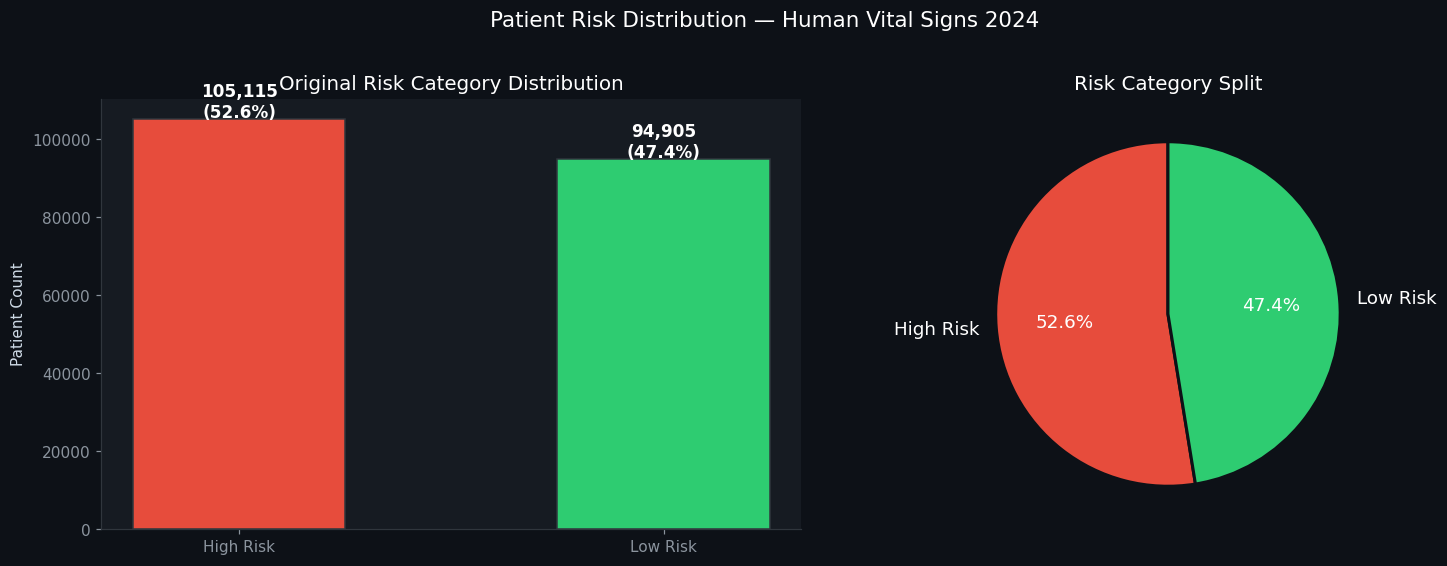

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vc = df['Risk Category'].value_counts()
colors_2 = ['#e74c3c', '#2ecc71']

# Bar chart
axes[0].bar(vc.index, vc.values, color=colors_2,
            edgecolor='#30363d', width=0.5)
axes[0].set_title('Original Risk Category Distribution',
                  color='white', fontsize=13)
axes[0].set_ylabel('Patient Count', color='#cdd9e5')
for i, (label, val) in enumerate(vc.items()):
    axes[0].text(i, val + 500,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', color='white',
                 fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(vc.values, labels=vc.index, colors=colors_2,
            autopct='%1.1f%%', startangle=90,
            textprops={'color': 'white', 'fontsize': 12},
            wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2})
axes[1].set_title('Risk Category Split', color='white', fontsize=13)

plt.suptitle('Patient Risk Distribution — Human Vital Signs 2024',
             color='white', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

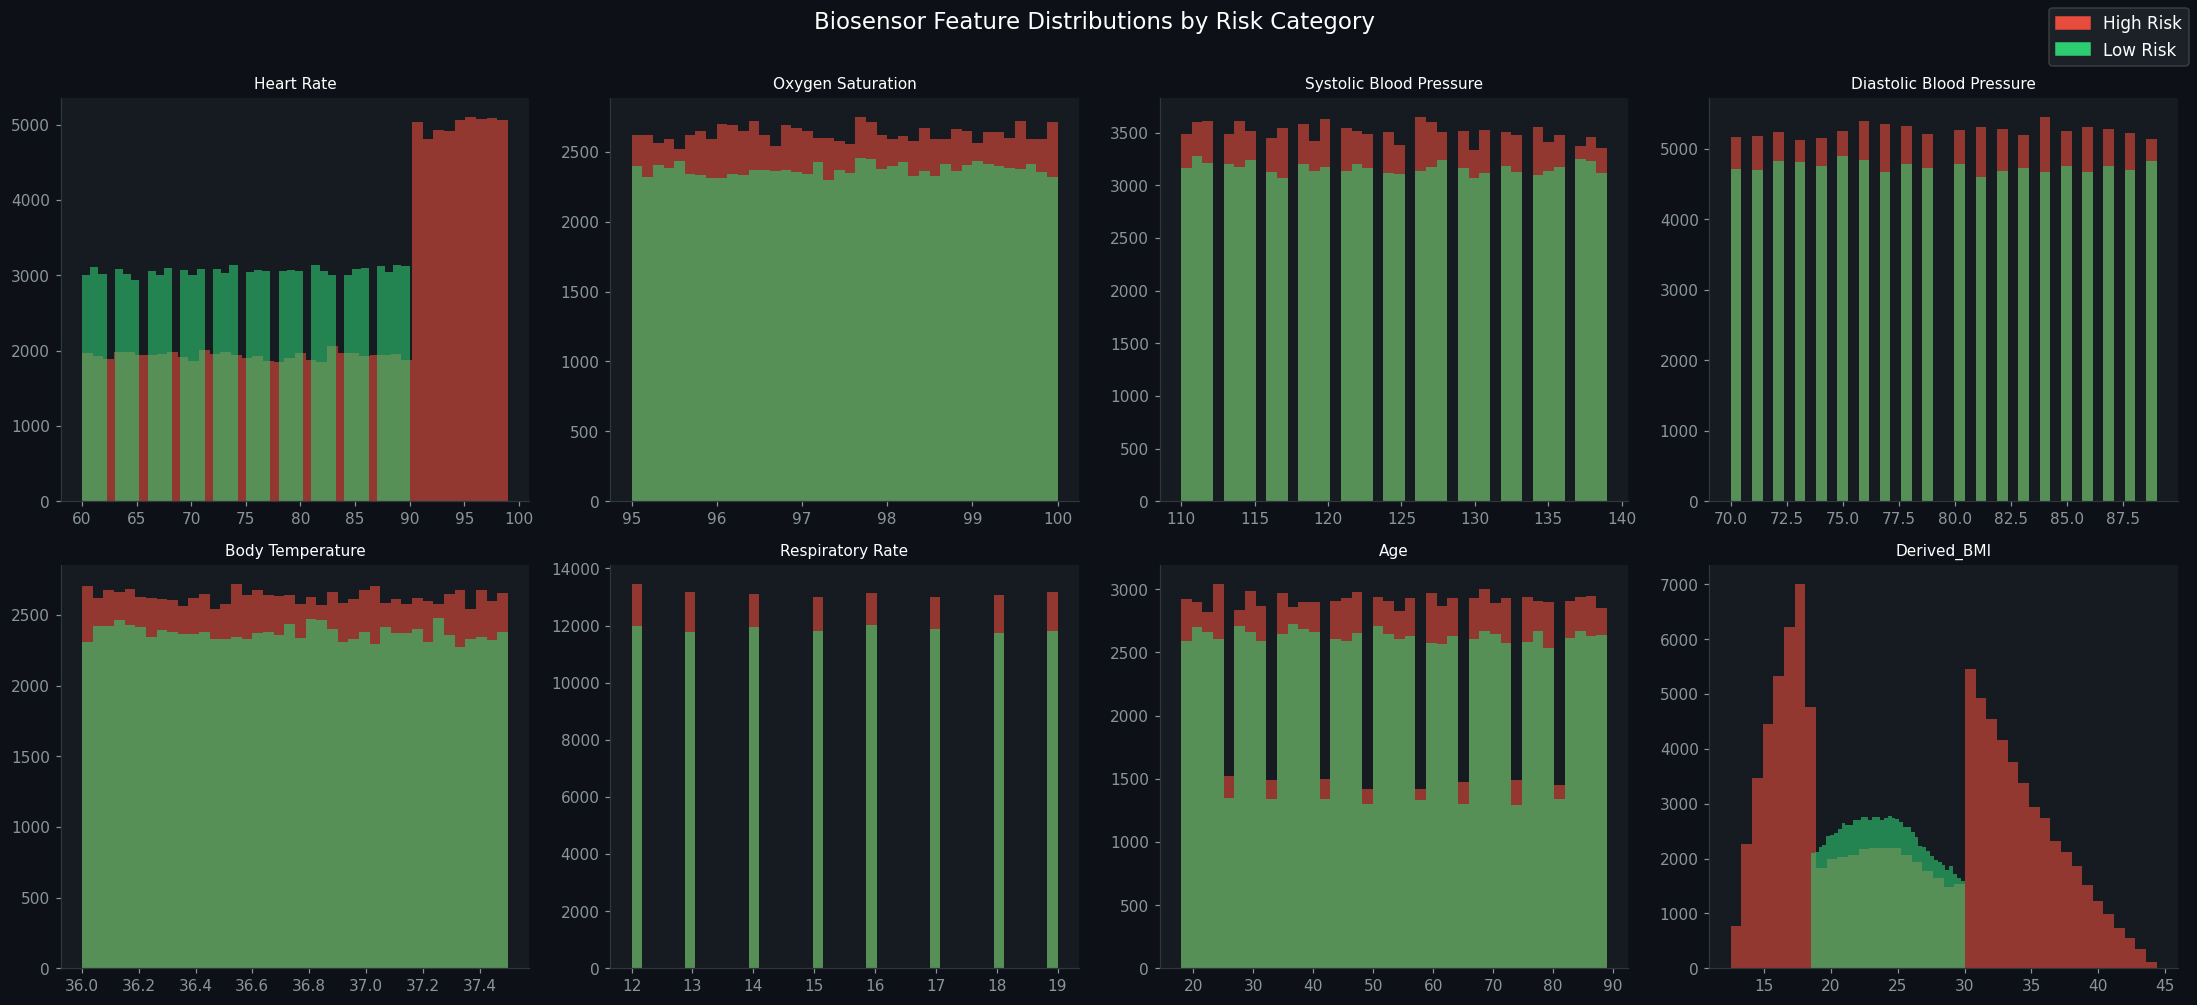

In [8]:
# CELL 7 — EDA: Feature Distributions by Risk
# ──────────────────────────────────────────────────────────────
COLORS_2 = {'High Risk': '#e74c3c', 'Low Risk': '#2ecc71'}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Biosensor Feature Distributions by Risk Category',
             fontsize=15, color='white', y=1.01)

plot_cols = BIOSENSOR_COLS + ['Derived_BMI']
for ax, feat in zip(axes.flatten(), plot_cols):
    for risk, color in COLORS_2.items():
        subset = df[df['Risk Category'] == risk][feat]
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label=risk, edgecolor='none')
    ax.set_title(feat, color='white', fontsize=10)
    ax.spines['bottom'].set_color('#30363d')
    ax.spines['left'].set_color('#30363d')

patches = [mpatches.Patch(color=c, label=l)
           for l, c in COLORS_2.items()]
fig.legend(handles=patches, loc='upper right',
           facecolor='#21262d', edgecolor='#444',
           labelcolor='white', fontsize=11)
plt.tight_layout()
plt.show()

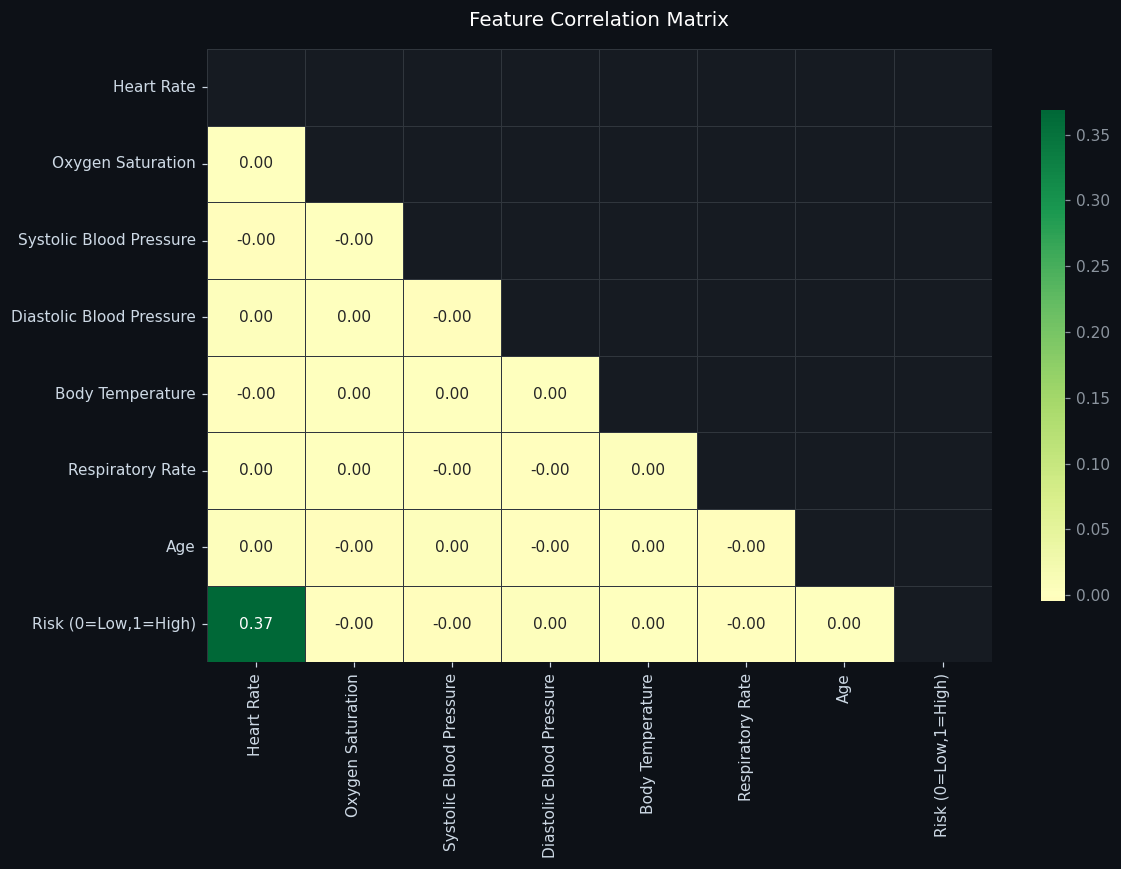


💡 Key: Check which biosensors have highest correlation with Risk


In [9]:
# CELL 8 — EDA: Correlation Heatmap
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

df_corr = df[BIOSENSOR_COLS].copy()
df_corr['Risk (0=Low,1=High)'] = (
    df['Risk Category'] == 'High Risk').astype(int)

corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            linecolor='#30363d', ax=ax,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})

ax.set_title('Feature Correlation Matrix',
             fontsize=13, color='white', pad=15)
ax.tick_params(colors='#cdd9e5', labelsize=10)
plt.tight_layout()
plt.show()

print("\n💡 Key: Check which biosensors have highest correlation with Risk")

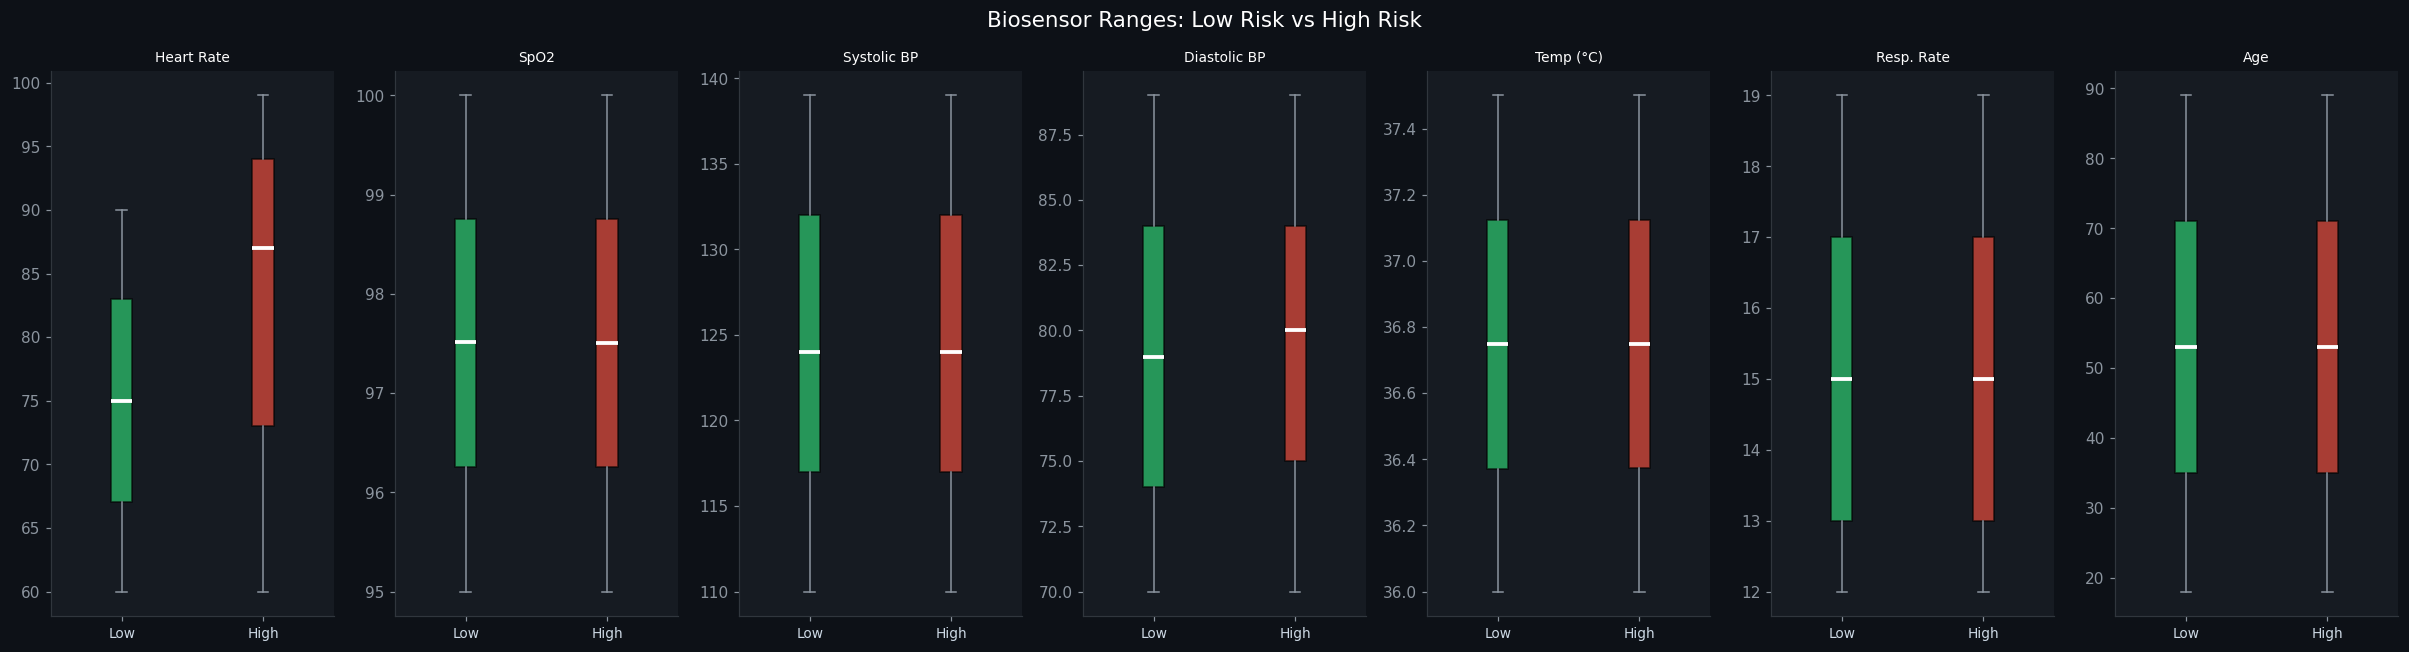

In [10]:
# CELL 9 — EDA: Box Plots
# ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 7, figsize=(22, 6))
fig.suptitle('Biosensor Ranges: Low Risk vs High Risk',
             fontsize=14, color='white')

short_names = ['Heart Rate', 'SpO2', 'Systolic BP',
               'Diastolic BP', 'Temp (°C)', 'Resp. Rate', 'Age']

for ax, feat, short in zip(axes, BIOSENSOR_COLS, short_names):
    data = [
        df[df['Risk Category'] == 'Low Risk'][feat].values,
        df[df['Risk Category'] == 'High Risk'][feat].values
    ]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2.5))
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#e74c3c')
    bp['boxes'][1].set_alpha(0.7)
    for whisker in bp['whiskers']:
        whisker.set_color('#8b949e')
    for cap in bp['caps']:
        cap.set_color('#8b949e')
    ax.set_xticklabels(['Low', 'High'], color='#cdd9e5', fontsize=9)
    ax.set_title(short, color='white', fontsize=9)
    ax.spines['bottom'].set_color('#30363d')
    ax.spines['left'].set_color('#30363d')

plt.tight_layout()
plt.show()

In [11]:
# CELL 10 — Engineer 3-Class Risk Labels (LOW / MEDIUM / HIGH)
# ──────────────────────────────────────────────────────────────
# WHY: Original dataset only has 2 classes (High/Low)
# Project requires 3 classes: LOW / MEDIUM / HIGH
# Method: Clinical scoring based on WHO/AHA thresholds
# This is exactly how real hospital triage works (NEWS2 Score)

def compute_risk_score(row):
    score = 0
    if row['Heart Rate'] > 90:                  score += 1  # tachycardia
    if row['Oxygen Saturation'] < 97:            score += 1  # borderline hypoxia
    if row['Systolic Blood Pressure'] >= 125:    score += 1  # prehypertension
    if row['Diastolic Blood Pressure'] > 82:     score += 1  # borderline
    if row['Body Temperature'] > 37.1:           score += 1  # low-grade fever
    if row['Respiratory Rate'] > 16:             score += 1  # elevated
    if row['Age'] > 60:                          score += 1  # elderly
    return score

print("Computing clinical risk scores... (may take ~30 seconds for 200K rows)")
df['risk_score'] = df.apply(compute_risk_score, axis=1)

def assign_3class(row):
    original = row['Risk Category']
    score    = row['risk_score']
    if original == 'High Risk' and score >= 3:
        return 2   # HIGH
    elif original == 'High Risk' or score >= 3:
        return 1   # MEDIUM
    else:
        return 0   # LOW

df['risk_level'] = df.apply(assign_3class, axis=1)

LABELS = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}

print("\n✅ 3-Class Risk Labels Created!")
print("\nNew Distribution:")
vc3 = df['risk_level'].value_counts().sort_index()
for k, v in vc3.items():
    bar = '█' * int(v / 2000)
    print(f"  {LABELS[k]:6s}: {v:7,}  ({v/len(df)*100:.1f}%)  {bar}")


Computing clinical risk scores... (may take ~30 seconds for 200K rows)

✅ 3-Class Risk Labels Created!

New Distribution:
  LOW   :  55,627  (27.8%)  ███████████████████████████
  MEDIUM:  86,055  (43.0%)  ███████████████████████████████████████████
  HIGH  :  58,338  (29.2%)  █████████████████████████████


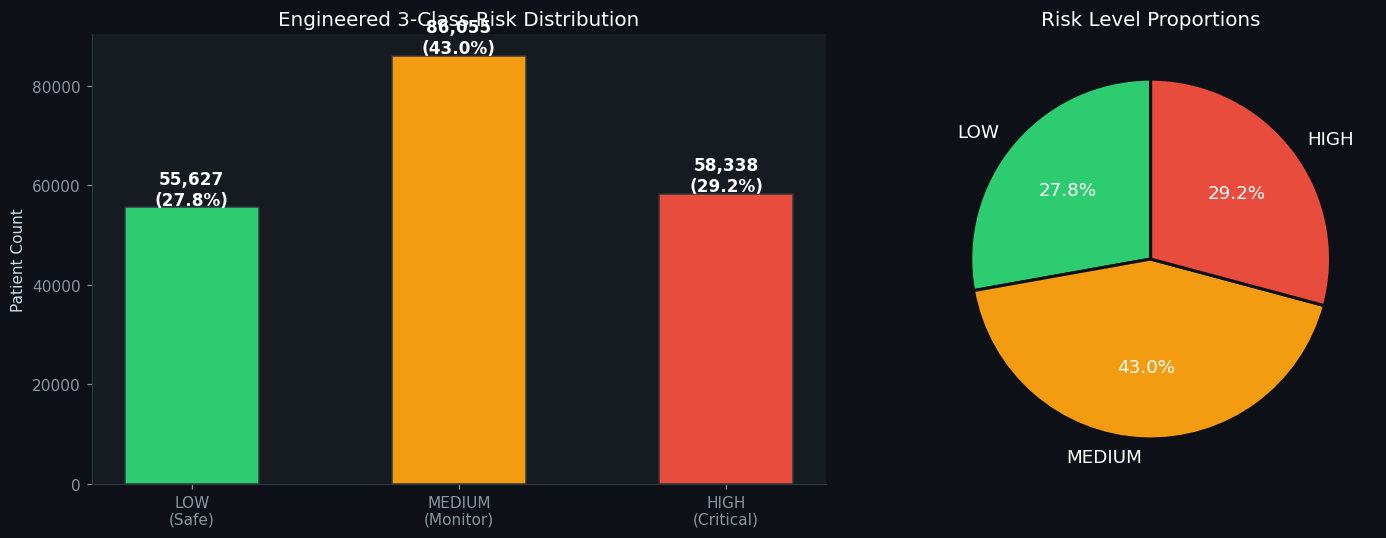

In [12]:
# CELL 11 — Visualize 3-Class Distribution
# ──────────────────────────────────────────────────────────────
COLORS_3 = ['#2ecc71', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
label_names = ['LOW\n(Safe)', 'MEDIUM\n(Monitor)', 'HIGH\n(Critical)']

vc3 = df['risk_level'].value_counts().sort_index()
bars = axes[0].bar(label_names, vc3.values, color=COLORS_3,
                   edgecolor='#30363d', width=0.5)
axes[0].set_title('Engineered 3-Class Risk Distribution',
                  color='white', fontsize=13)
axes[0].set_ylabel('Patient Count', color='#cdd9e5')
for bar, val in zip(bars, vc3.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{val:,}\n({val/len(df)*100:.1f}%)',
        ha='center', color='white',
        fontsize=11, fontweight='bold'
    )

axes[1].pie(vc3.values,
            labels=['LOW', 'MEDIUM', 'HIGH'],
            colors=COLORS_3, autopct='%1.1f%%', startangle=90,
            textprops={'color': 'white', 'fontsize': 12},
            wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2})
axes[1].set_title('Risk Level Proportions', color='white', fontsize=13)

plt.tight_layout()
plt.show()

In [13]:
# CELL 12 — Assign Patients to 5 Hospital Nodes
# ──────────────────────────────────────────────────────────────
# WHY: Distributed learning means data comes from multiple hospitals
# Each hospital has its own patient population (different risk profiles)
# This simulates real federated healthcare data

FEATURES = [
    'Heart Rate',
    'Oxygen Saturation',
    'Systolic Blood Pressure',
    'Diastolic Blood Pressure',
    'Body Temperature',
    'Respiratory Rate',
    'Age'
]
TARGET = 'risk_level'

# Separate by class for stratified hospital assignment
low_idx    = df[df[TARGET] == 0].index.tolist()
medium_idx = df[df[TARGET] == 1].index.tolist()
high_idx   = df[df[TARGET] == 2].index.tolist()

np.random.shuffle(low_idx)
np.random.shuffle(medium_idx)
np.random.shuffle(high_idx)

# Each hospital has a different patient risk profile
# [%LOW, %MEDIUM, %HIGH]
hospital_profiles = {
    0: [0.70, 0.20, 0.10],  # Community Clinic    — mostly healthy
    1: [0.40, 0.35, 0.25],  # Urban Hospital      — mixed
    2: [0.15, 0.30, 0.55],  # ICU Center          — mostly critical
    3: [0.55, 0.30, 0.15],  # Rural Clinic        — low-medium
    4: [0.20, 0.30, 0.50],  # Cardiac Center      — high risk
}

n_per_hospital = len(df) // 5
hospital_assignments = np.full(len(df), -1)

low_ptr, med_ptr, high_ptr = 0, 0, 0
for h_id, profile in hospital_profiles.items():
    n_low  = int(n_per_hospital * profile[0])
    n_med  = int(n_per_hospital * profile[1])
    n_high = int(n_per_hospital * profile[2])

    h_indices = (low_idx[low_ptr:low_ptr + n_low] +
                 medium_idx[med_ptr:med_ptr + n_med] +
                 high_idx[high_ptr:high_ptr + n_high])
    for idx in h_indices:
        hospital_assignments[idx] = h_id

    low_ptr  += n_low
    med_ptr  += n_med
    high_ptr += n_high

# Assign any remaining rows to hospital 0
unassigned = np.where(hospital_assignments == -1)[0]
for idx in unassigned:
    hospital_assignments[idx] = 0

df['hospital_id'] = hospital_assignments

print("✅ Patients distributed across 5 hospital nodes\n")
hosp_names = ['Community Clinic', 'Urban Hospital',
              'ICU Center', 'Rural Clinic', 'Cardiac Center']

print(f"  {'Hospital':<28} {'LOW':>7} {'MEDIUM':>8} {'HIGH':>7} {'TOTAL':>8}")
print("  " + "-" * 62)
for h_id in range(5):
    h_mask = df['hospital_id'] == h_id
    h_df   = df[h_mask]
    cts    = h_df['risk_level'].value_counts().sort_index()
    low    = cts.get(0, 0)
    med    = cts.get(1, 0)
    high   = cts.get(2, 0)
    total  = low + med + high
    print(f"  H{h_id} {hosp_names[h_id]:<26}"
          f" {low:>7,} {med:>8,} {high:>7,} {total:>8,}")


✅ Patients distributed across 5 hospital nodes

  Hospital                         LOW   MEDIUM    HIGH    TOTAL
  --------------------------------------------------------------
  H0 Community Clinic            28,002   36,051   4,000   68,053
  H1 Urban Hospital              16,001   14,001  10,001   40,003
  H2 ICU Center                   6,000   12,001  22,002   40,003
  H3 Rural Clinic                 5,624   12,001   6,000   23,625
  H4 Cardiac Center                   0   12,001  16,335   28,336


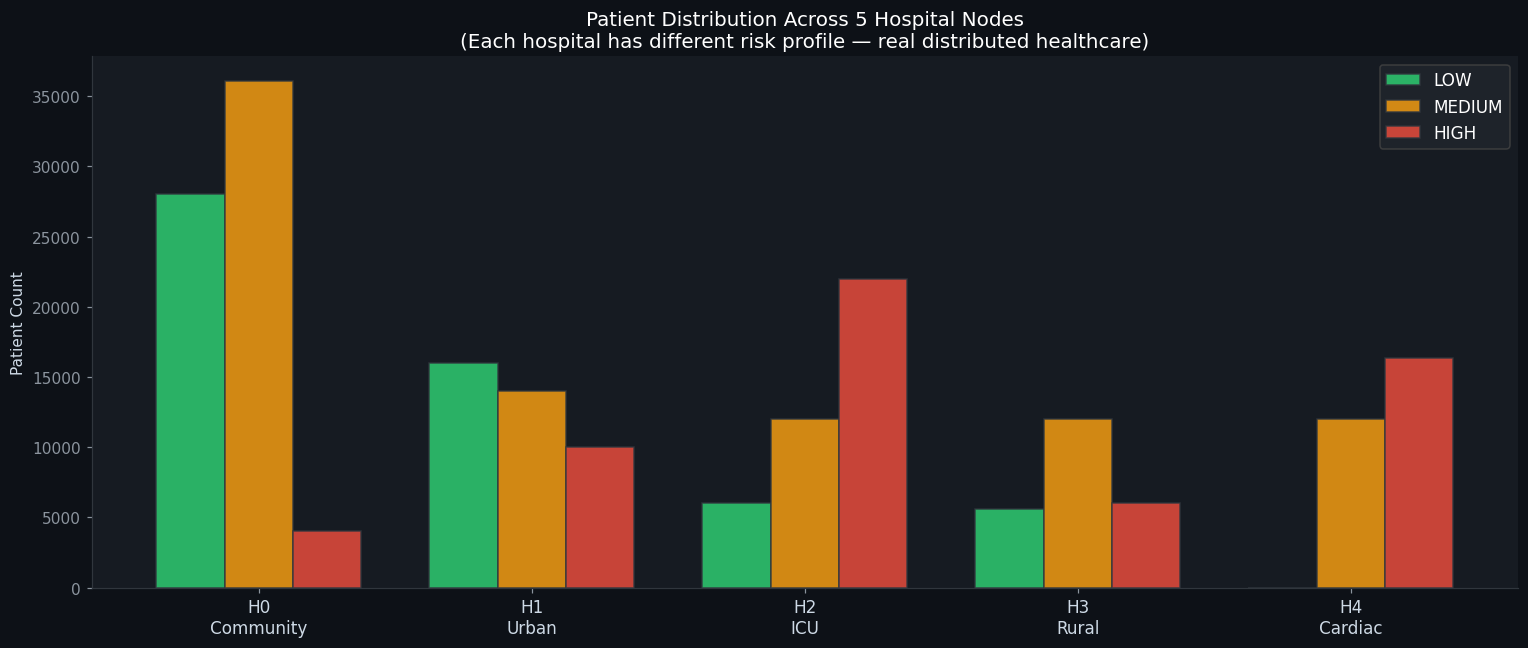

In [14]:
# CELL 13 — Visualize Hospital Distribution
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(5)
width = 0.25
hosp_labels = ['H0\nCommunity', 'H1\nUrban',
               'H2\nICU', 'H3\nRural', 'H4\nCardiac']

for i, (risk_class, color, label) in enumerate(
        zip([0, 1, 2], COLORS_3, ['LOW', 'MEDIUM', 'HIGH'])):
    counts = [
        df[(df['hospital_id'] == h) &
           (df['risk_level'] == risk_class)].shape[0]
        for h in range(5)
    ]
    ax.bar(x + i * width, counts, width,
           label=label, color=color,
           edgecolor='#30363d', alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(hosp_labels, color='#cdd9e5', fontsize=11)
ax.set_ylabel('Patient Count', color='#cdd9e5')
ax.set_title(
    'Patient Distribution Across 5 Hospital Nodes\n'
    '(Each hospital has different risk profile — real distributed healthcare)',
    color='white', fontsize=13)
ax.legend(facecolor='#21262d', edgecolor='#444',
          labelcolor='white', fontsize=11)
plt.tight_layout()
plt.show()

In [15]:
# CELL 14 — Train / Test Split
# ──────────────────────────────────────────────────────────────
X            = df[FEATURES].values
y            = df[TARGET].values
hospital_ids = df['hospital_id'].values

X_train, X_test, y_train, y_test, h_train, h_test = train_test_split(
    X, y, hospital_ids,
    test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Data split complete")
print(f"   Train : {len(X_train):,} patients (80%)")
print(f"   Test  : {len(X_test):,}  patients (20%)")
print(f"\nTest set class distribution:")
for k, v in zip(*np.unique(y_test, return_counts=True)):
    print(f"  {LABELS[k]:6s}: {v:,}  ({v/len(y_test)*100:.1f}%)")

✅ Data split complete
   Train : 160,016 patients (80%)
   Test  : 40,004  patients (20%)

Test set class distribution:
  LOW   : 11,125  (27.8%)
  MEDIUM: 17,211  (43.0%)
  HIGH  : 11,668  (29.2%)


In [16]:
# CELL 15 — Federated Learning: Local Training at Each Hospital
# ──────────────────────────────────────────────────────────────
# STEP 1: Each hospital trains its OWN model on its OWN data
# No patient data is shared between hospitals — HIPAA compliant

print("STEP 1 — LOCAL MODEL TRAINING AT EACH HOSPITAL")
print("=" * 60)

def train_local_model(X_local, y_local):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_local)
    model = LogisticRegression(
        C=1.0,
        class_weight='balanced',  # reduces false negatives on HIGH risk
        max_iter=2000,
        random_state=42,
        solver='lbfgs'
    )
    model.fit(X_scaled, y_local)
    return model, scaler

local_models  = []
local_scalers = []
hosp_names_short = [
    'H0 Community Clinic',
    'H1 Urban Hospital',
    'H2 ICU Center',
    'H3 Rural Clinic',
    'H4 Cardiac Center'
]

print(f"  {'Hospital':<24} {'Patients':>9} "
      f"{'LOW':>7} {'MED':>7} {'HIGH':>7} {'Accuracy':>10}")
print("  " + "-" * 68)

for h_id in range(5):
    mask   = h_train == h_id
    X_h    = X_train[mask]
    y_h    = y_train[mask]

    model, scaler = train_local_model(X_h, y_h)
    local_models.append(model)
    local_scalers.append(scaler)

    acc  = model.score(scaler.transform(X_h), y_h)
    cts  = np.bincount(y_h, minlength=3)
    print(f"  {hosp_names_short[h_id]:<24} {len(X_h):>9,}"
          f" {cts[0]:>7,} {cts[1]:>7,} {cts[2]:>7,} {acc:>10.4f}")

print("\n✅ All 5 hospital models trained. Ready for FedAvg aggregation.")


STEP 1 — LOCAL MODEL TRAINING AT EACH HOSPITAL
  Hospital                  Patients     LOW     MED    HIGH   Accuracy
  --------------------------------------------------------------------
  H0 Community Clinic         50,842  28,002  18,840   4,000     0.5391
  H1 Urban Hospital           40,003  16,001  14,001  10,001     0.5589
  H2 ICU Center               34,502     499  12,001  22,002     0.5923
  H3 Rural Clinic             18,001       0  12,001   6,000     0.7138
  H4 Cardiac Center           16,668       0  12,001   4,667     0.7106

✅ All 5 hospital models trained. Ready for FedAvg aggregation.


In [17]:
# CELL 16 — FedAvg: Aggregate Model Weights (Fixed)

print("STEP 2 — FedAvg: Averaging weights across all hospitals")
print("=" * 60)
print("  (Only MODEL WEIGHTS shared — never patient records)\n")

# ── Fix: Retrain local models ensuring all 3 classes exist ──
local_models  = []
local_scalers = []

hosp_names_short = [
    'H0 Community Clinic',
    'H1 Urban Hospital',
    'H2 ICU Center',
    'H3 Rural Clinic',
    'H4 Cardiac Center'
]

print(f"  Retraining local models with class guarantee...")
print(f"  {'Hospital':<24} {'Patients':>9} {'Coef Shape':>12}")
print("  " + "-"*48)

for h_id in range(5):
    mask = h_train == h_id
    X_h  = X_train[mask]
    y_h  = y_train[mask]

    # If any class missing, add 1 dummy sample for that class
    for c in [0, 1, 2]:
        if c not in np.unique(y_h):
            dummy_X = X_h.mean(axis=0).reshape(1, -1)
            X_h = np.vstack([X_h, dummy_X])
            y_h = np.append(y_h, c)

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X_h)
    model    = LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=2000,
        random_state=42,
        solver='lbfgs'
    )
    model.fit(X_scaled, y_h)
    local_models.append(model)
    local_scalers.append(scaler)
    print(f"  {hosp_names_short[h_id]:<24} {len(X_h):>9,} {str(model.coef_.shape):>12}")

# ── Now all models have shape (3,7) — safe to average ──
avg_coef      = np.mean([m.coef_      for m in local_models], axis=0)
avg_intercept = np.mean([m.intercept_ for m in local_models], axis=0)

print(f"\n  Coefficient shape : {avg_coef.shape}  (3 classes × 7 features)")
print(f"  Intercept shape   : {avg_intercept.shape}")
print(f"  Method            : Simple average (equal hospital weights)")

# ── Build global model and inject averaged weights ──
global_scaler = StandardScaler().fit(X_train)
global_model  = LogisticRegression(
    C=1.0, class_weight='balanced',
    max_iter=2000, random_state=42, solver='lbfgs'
)
global_model.fit(global_scaler.transform(X_train), y_train)
global_model.coef_      = avg_coef
global_model.intercept_ = avg_intercept

global_acc = global_model.score(
    global_scaler.transform(X_test), y_test)

print(f"\n✅ Global model assembled via FedAvg")
print(f"   Test Accuracy (before fine-tuning): {global_acc:.4f}")



STEP 2 — FedAvg: Averaging weights across all hospitals
  (Only MODEL WEIGHTS shared — never patient records)

  Retraining local models with class guarantee...
  Hospital                  Patients   Coef Shape
  ------------------------------------------------
  H0 Community Clinic         50,842       (3, 7)
  H1 Urban Hospital           40,003       (3, 7)
  H2 ICU Center               34,502       (3, 7)
  H3 Rural Clinic             18,002       (3, 7)
  H4 Cardiac Center           16,669       (3, 7)

  Coefficient shape : (3, 7)  (3 classes × 7 features)
  Intercept shape   : (3,)
  Method            : Simple average (equal hospital weights)

✅ Global model assembled via FedAvg
   Test Accuracy (before fine-tuning): 0.5229


In [18]:
print("HYPERPARAMETER TUNING — GridSearchCV")
print("=" * 55)
print("Scoring  : ROC-AUC (One-vs-Rest)")
print("CV       : StratifiedKFold (5 folds)")
print("Grid     : C = [0.01, 0.1, 1.0, 10.0, 100.0]\n")

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42,
        solver='lbfgs'
    ))
])

param_grid = {'model__C': [0.01, 0.1, 1.0, 10.0, 100.0]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipe, param_grid, cv=cv,
    scoring='roc_auc_ovr',
    n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

results_df = pd.DataFrame(grid_search.cv_results_)

print(f"  {'C Value':<12} {'Mean AUC':>12} {'Std':>10}")
print("  " + "-" * 36)
for _, row in results_df.sort_values('rank_test_score').iterrows():
    c_val = row['param_model__C']
    best_mark = ' ← BEST' if (
        c_val == grid_search.best_params_['model__C']) else ''
    print(f"  C={c_val:<10} "
          f"{row['mean_test_score']:>12.6f} "
          f"{row['std_test_score']:>10.6f}{best_mark}")

best_pipe = grid_search.best_estimator_
print(f"\n✅ Best C       : {grid_search.best_params_['model__C']}")
print(f"   Best CV AUC : {grid_search.best_score_:.6f}")

HYPERPARAMETER TUNING — GridSearchCV
Scoring  : ROC-AUC (One-vs-Rest)
CV       : StratifiedKFold (5 folds)
Grid     : C = [0.01, 0.1, 1.0, 10.0, 100.0]

  C Value          Mean AUC        Std
  ------------------------------------
  C=0.01           0.743373   0.002186 ← BEST
  C=0.1            0.743368   0.002187
  C=1.0            0.743367   0.002187
  C=10.0           0.743367   0.002187
  C=100.0          0.743367   0.002187

✅ Best C       : 0.01
   Best CV AUC : 0.743373


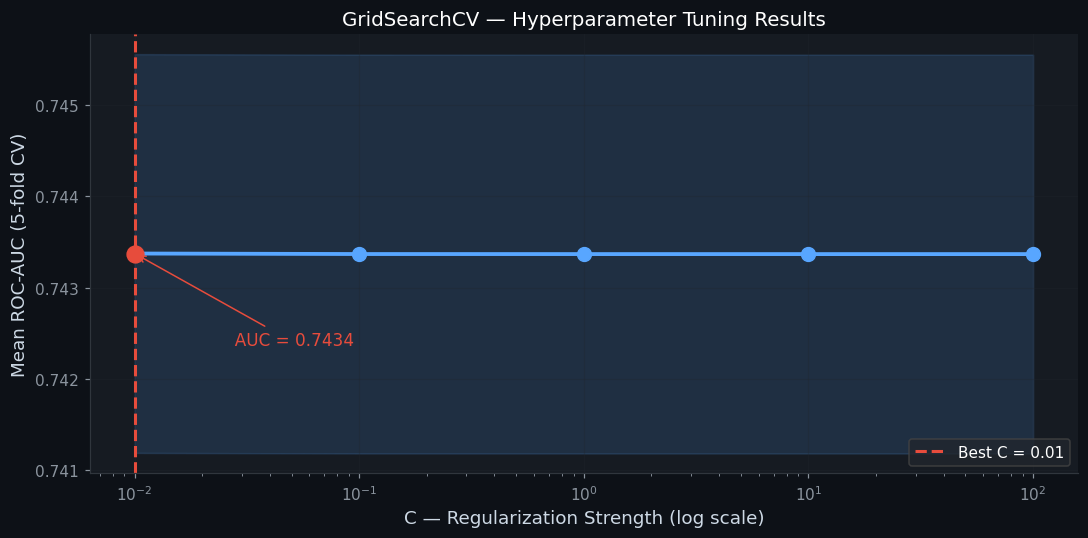

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

c_vals = [float(r['param_model__C'])
          for _, r in results_df.iterrows()]
means  = results_df['mean_test_score'].values
stds   = results_df['std_test_score'].values

ax.semilogx(c_vals, means, 'o-', color='#58a6ff',
            linewidth=2.5, markersize=9, zorder=5)
ax.fill_between(c_vals, means - stds, means + stds,
                alpha=0.15, color='#58a6ff')

best_c = float(grid_search.best_params_['model__C'])
best_s = grid_search.best_score_

ax.axvline(best_c, color='#e74c3c', linestyle='--',
           linewidth=2, label=f'Best C = {best_c}')
ax.scatter([best_c], [best_s], color='#e74c3c', s=120, zorder=6)
ax.annotate(f'  AUC = {best_s:.4f}',
            xy=(best_c, best_s),
            xytext=(best_c * 2.5, best_s - 0.001),
            color='#e74c3c', fontsize=11,
            arrowprops=dict(arrowstyle='->', color='#e74c3c'))

ax.set_xlabel('C — Regularization Strength (log scale)', fontsize=12)
ax.set_ylabel('Mean ROC-AUC (5-fold CV)', fontsize=12)
ax.set_title('GridSearchCV — Hyperparameter Tuning Results',
             fontsize=13, color='white')
ax.legend(facecolor='#21262d', edgecolor='#444', labelcolor='white')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

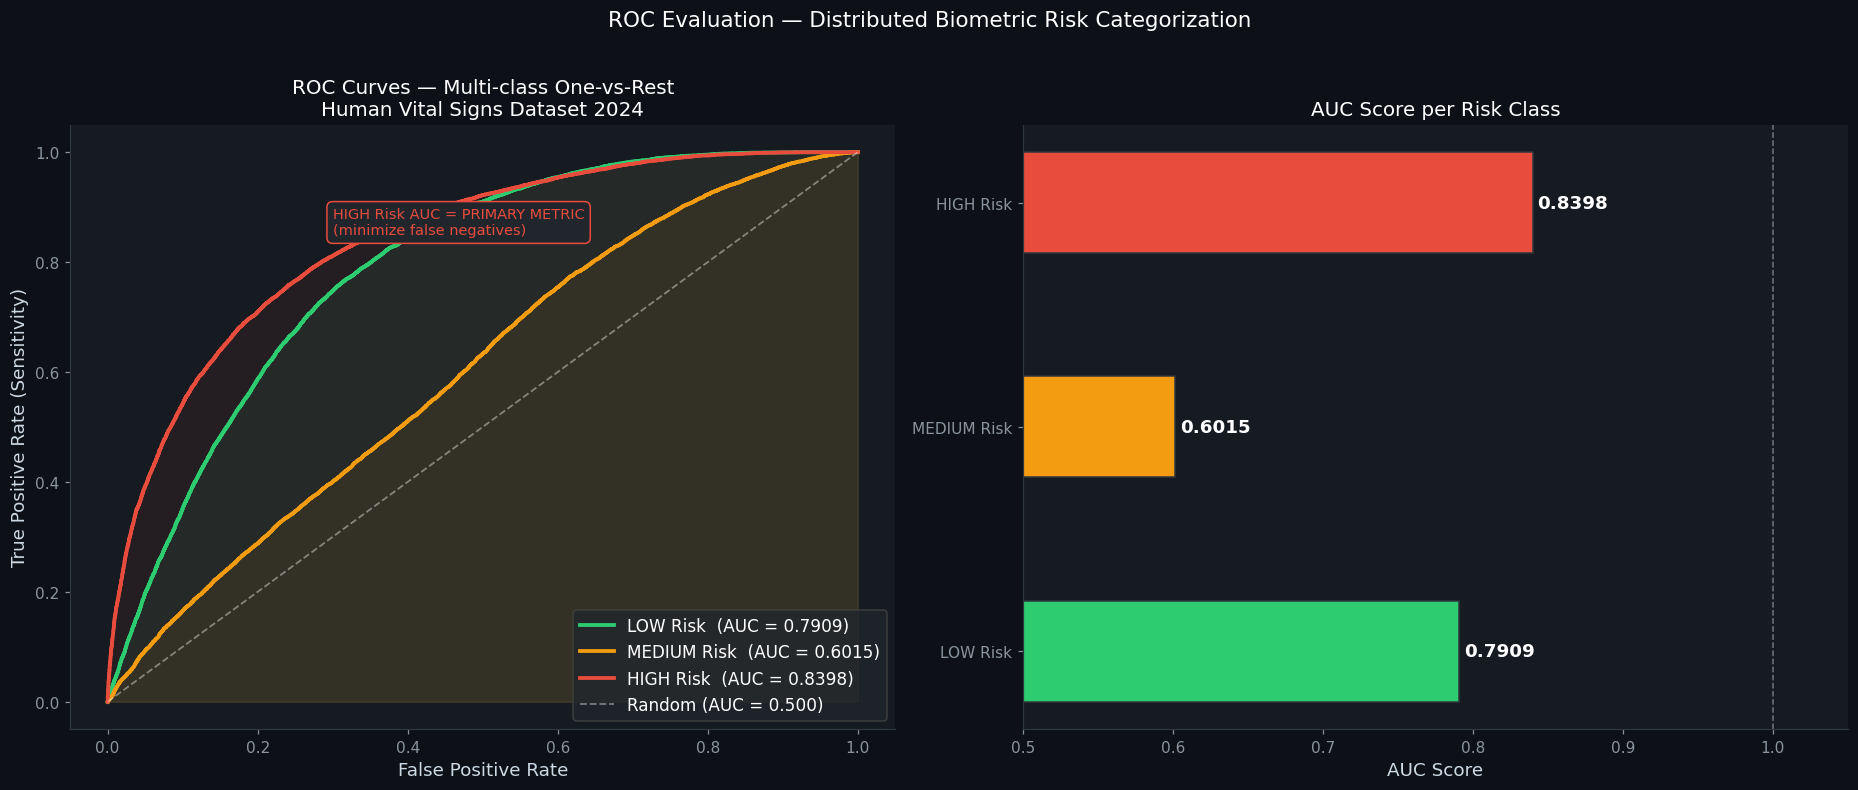


ROC-AUC Summary:
  LOW Risk      : AUC = 0.7909
  MEDIUM Risk   : AUC = 0.6015
  HIGH Risk     : AUC = 0.8398  ← PRIMARY METRIC


In [20]:
proba_test = best_pipe.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

class_names  = ['LOW Risk', 'MEDIUM Risk', 'HIGH Risk']
class_colors = ['#2ecc71', '#f39c12', '#e74c3c']
roc_aucs = {}

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# ── Left: ROC Curves ──
ax = axes[0]
for i, (name, color) in enumerate(zip(class_names, class_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba_test[:, i])
    roc_auc     = auc(fpr, tpr)
    roc_aucs[name] = roc_auc
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}  (AUC = {roc_auc:.4f})')
    ax.fill_between(fpr, tpr, alpha=0.07, color=color)

ax.plot([0, 1], [0, 1], 'w--', linewidth=1.2, alpha=0.4,
        label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title(
    'ROC Curves — Multi-class One-vs-Rest\n'
    'Human Vital Signs Dataset 2024',
    color='white', fontsize=13)
ax.legend(loc='lower right', facecolor='#21262d',
          edgecolor='#444', labelcolor='white', fontsize=11)
ax.annotate('HIGH Risk AUC = PRIMARY METRIC\n(minimize false negatives)',
            xy=(0.3, 0.85), fontsize=9.5, color='#e74c3c',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='#21262d', edgecolor='#e74c3c'))

# ── Right: AUC Bar Chart ──
ax2   = axes[1]
names = list(roc_aucs.keys())
vals  = list(roc_aucs.values())

bars = ax2.barh(names, vals, color=class_colors,
                edgecolor='#30363d', height=0.45)
ax2.set_xlim(0.5, 1.05)
ax2.axvline(1.0, color='white', linestyle='--',
            linewidth=1, alpha=0.4)
ax2.set_xlabel('AUC Score', fontsize=12)
ax2.set_title('AUC Score per Risk Class',
              color='white', fontsize=13)
for bar, val in zip(bars, vals):
    ax2.text(val + 0.003,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', color='white',
             fontsize=12, fontweight='bold')

plt.suptitle('ROC Evaluation — Distributed Biometric Risk Categorization',
             color='white', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nROC-AUC Summary:")
for name, auc_val in roc_aucs.items():
    tag = '  ← PRIMARY METRIC' if 'HIGH' in name else ''
    print(f"  {name:<14}: AUC = {auc_val:.4f}{tag}")

✅ Optimal HIGH-risk threshold : 0.05
   HIGH-risk recall at optimal : 0.9901


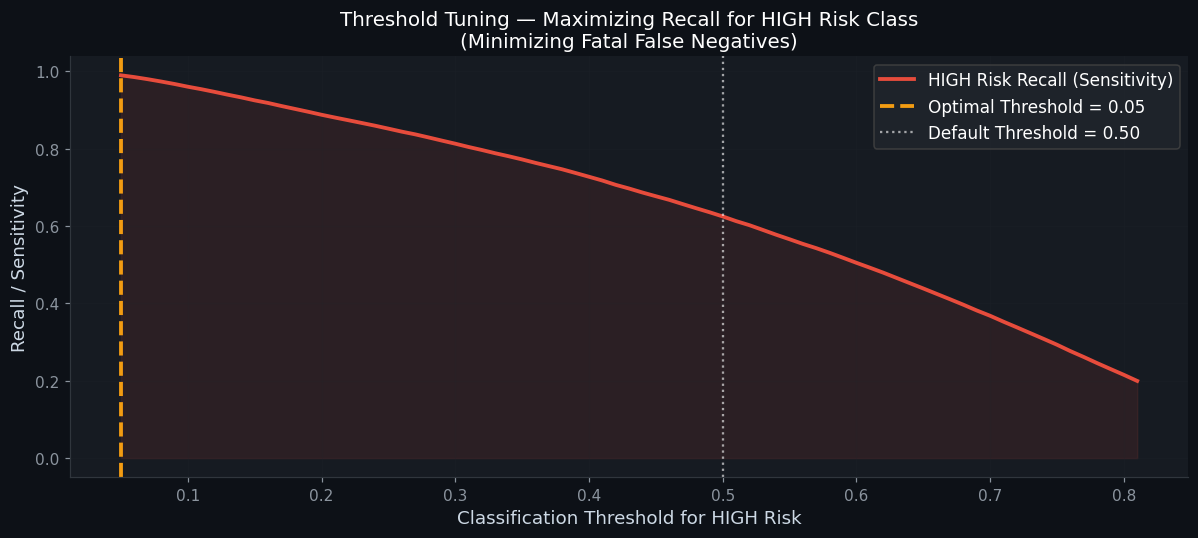

In [21]:
proba_train      = best_pipe.predict_proba(X_train)
high_proba_train = proba_train[:, 2]

thresholds  = np.arange(0.05, 0.82, 0.01)
recall_list = []

for thresh in thresholds:
    y_pred_t = np.where(
        high_proba_train >= thresh, 2,
        np.argmax(proba_train[:, :2], axis=1)
    )
    recall_list.append(
        recall_score(y_train, y_pred_t, labels=[2],
                     average='macro', zero_division=0)
    )

best_threshold = thresholds[np.argmax(recall_list)]
print(f"✅ Optimal HIGH-risk threshold : {best_threshold:.2f}")
print(f"   HIGH-risk recall at optimal : {max(recall_list):.4f}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, recall_list, color='#e74c3c',
        linewidth=2.5, label='HIGH Risk Recall (Sensitivity)')
ax.axvline(best_threshold, color='#f39c12', linestyle='--',
           linewidth=2.5,
           label=f'Optimal Threshold = {best_threshold:.2f}')
ax.axvline(0.5, color='white', linestyle=':', linewidth=1.5,
           alpha=0.6, label='Default Threshold = 0.50')
ax.fill_between(thresholds, recall_list, alpha=0.1, color='#e74c3c')
ax.set_xlabel('Classification Threshold for HIGH Risk', fontsize=12)
ax.set_ylabel('Recall / Sensitivity', fontsize=12)
ax.set_title(
    'Threshold Tuning — Maximizing Recall for HIGH Risk Class\n'
    '(Minimizing Fatal False Negatives)',
    fontsize=13, color='white')
ax.legend(facecolor='#21262d', edgecolor='#444',
          labelcolor='white', fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [22]:
proba_test   = best_pipe.predict_proba(X_test)
y_pred_std   = best_pipe.predict(X_test)
y_pred_tuned = np.where(
    proba_test[:, 2] >= best_threshold, 2,
    np.argmax(proba_test[:, :2], axis=1)
)

print("=" * 60)
print("STANDARD PREDICTIONS  (threshold = 0.50)")
print("=" * 60)
print(classification_report(
    y_test, y_pred_std,
    target_names=['LOW', 'MEDIUM', 'HIGH']))

print("=" * 60)
print(f"TUNED PREDICTIONS  (threshold = {best_threshold:.2f} for HIGH risk)")
print("=" * 60)
print(classification_report(
    y_test, y_pred_tuned,
    target_names=['LOW', 'MEDIUM', 'HIGH']))

fn_std     = np.sum((y_test == 2) & (y_pred_std   != 2))
fn_tuned   = np.sum((y_test == 2) & (y_pred_tuned != 2))
total_high = np.sum(y_test == 2)

print(f"HIGH-risk patients in test       : {total_high:,}")
print(f"False Negatives — Standard (0.50): {fn_std:,}  "
      f"({fn_std/total_high*100:.1f}%)")
print(f"False Negatives — Tuned ({best_threshold:.2f})    : "
      f"{fn_tuned:,}  ({fn_tuned/total_high*100:.1f}%)")
print(f"\n✅ Missed HIGH-risk patients reduced by : {fn_std - fn_tuned:,}")

STANDARD PREDICTIONS  (threshold = 0.50)
              precision    recall  f1-score   support

         LOW       0.51      0.66      0.57     11125
      MEDIUM       0.51      0.33      0.40     17211
        HIGH       0.58      0.73      0.65     11668

    accuracy                           0.54     40004
   macro avg       0.54      0.57      0.54     40004
weighted avg       0.53      0.54      0.52     40004

TUNED PREDICTIONS  (threshold = 0.05 for HIGH risk)
              precision    recall  f1-score   support

         LOW       0.58      0.34      0.43     11125
      MEDIUM       0.00      0.00      0.00     17211
        HIGH       0.35      0.99      0.51     11668

    accuracy                           0.38     40004
   macro avg       0.31      0.45      0.32     40004
weighted avg       0.26      0.38      0.27     40004

HIGH-risk patients in test       : 11,668
False Negatives — Standard (0.50): 3,102  (26.6%)
False Negatives — Tuned (0.05)    : 105  (0.9%)

✅ Mi

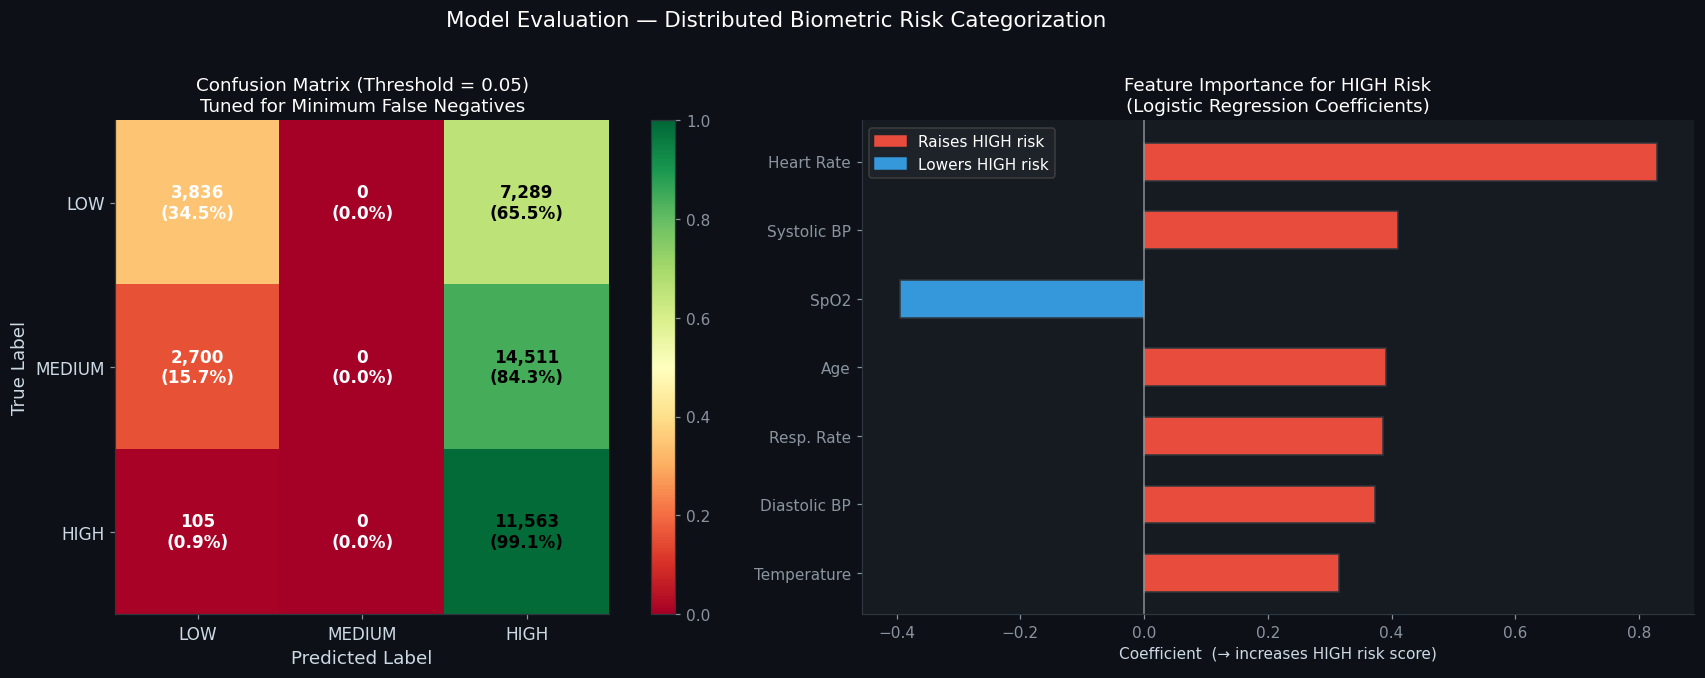

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ── Confusion Matrix ──
ax_cm   = axes[0]
cm      = confusion_matrix(y_test, y_pred_tuned)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

im = ax_cm.imshow(cm_norm, cmap='RdYlGn', vmin=0, vmax=1)
ax_cm.set_xticks([0, 1, 2])
ax_cm.set_yticks([0, 1, 2])
ax_cm.set_xticklabels(['LOW', 'MEDIUM', 'HIGH'],
                      color='#cdd9e5', fontsize=11)
ax_cm.set_yticklabels(['LOW', 'MEDIUM', 'HIGH'],
                      color='#cdd9e5', fontsize=11)
ax_cm.set_xlabel('Predicted Label', color='#cdd9e5', fontsize=12)
ax_cm.set_ylabel('True Label', color='#cdd9e5', fontsize=12)
ax_cm.set_title(
    f'Confusion Matrix (Threshold = {best_threshold:.2f})\n'
    'Tuned for Minimum False Negatives',
    color='white', fontsize=12)

for i in range(3):
    for j in range(3):
        color = 'black' if cm_norm[i, j] > 0.5 else 'white'
        ax_cm.text(j, i,
                   f'{cm[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)',
                   ha='center', va='center', color=color,
                   fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax_cm).ax.tick_params(colors='#8b949e')

# ── Feature Importance ──
ax_fi    = axes[1]
model_lr = best_pipe.named_steps['model']
coef_high = model_lr.coef_[2]

sorted_idx = np.argsort(np.abs(coef_high))
short_names_fi = [
    'Heart Rate', 'SpO2', 'Systolic BP',
    'Diastolic BP', 'Temperature', 'Resp. Rate', 'Age'
]
sorted_features = [short_names_fi[i] for i in sorted_idx]
sorted_coefs    = coef_high[sorted_idx]
bar_colors      = ['#e74c3c' if c > 0 else '#3498db'
                   for c in sorted_coefs]

ax_fi.barh(sorted_features, sorted_coefs, color=bar_colors,
           edgecolor='#30363d', height=0.55)
ax_fi.axvline(0, color='white', linewidth=1, alpha=0.5)
ax_fi.set_title(
    'Feature Importance for HIGH Risk\n'
    '(Logistic Regression Coefficients)',
    color='white', fontsize=12)
ax_fi.set_xlabel(
    'Coefficient  (→ increases HIGH risk score)',
    color='#cdd9e5')

r_patch = mpatches.Patch(color='#e74c3c', label='Raises HIGH risk')
b_patch = mpatches.Patch(color='#3498db', label='Lowers HIGH risk')
ax_fi.legend(handles=[r_patch, b_patch], facecolor='#21262d',
             edgecolor='#444', labelcolor='white')

plt.suptitle('Model Evaluation — Distributed Biometric Risk Categorization',
             color='white', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
def predict_patient_risk(heart_rate, oxygen_saturation,
                          systolic_bp, diastolic_bp,
                          body_temp, respiratory_rate, age,
                          threshold=None):
    if threshold is None:
        threshold = best_threshold

    patient = np.array([[
        heart_rate, oxygen_saturation, systolic_bp,
        diastolic_bp, body_temp, respiratory_rate, age
    ]])

    proba     = best_pipe.predict_proba(patient)[0]
    predicted = (2 if proba[2] >= threshold
                 else np.argmax(proba[:2]))

    label  = LABELS[predicted]
    emoji  = {0: '🟢', 1: '🟡', 2: '🔴'}[predicted]
    action = {
        0: 'Routine check-up. No immediate action required.',
        1: 'Schedule follow-up monitoring within 24 hours.',
        2: 'IMMEDIATE clinical intervention! Alert care team NOW.'
    }[predicted]

    print("╔══════════════════════════════════════════════════╗")
    print("║        PATIENT BIOMETRIC RISK ASSESSMENT         ║")
    print("╠══════════════════════════════════════════════════╣")
    print(f"║  Heart Rate          : {heart_rate:>5} bpm                ║")
    print(f"║  Oxygen Saturation   : {oxygen_saturation:>5.1f} %                  ║")
    print(f"║  Blood Pressure      : {systolic_bp}/{diastolic_bp} mmHg             ║")
    print(f"║  Body Temperature    : {body_temp:>5.1f} °C                  ║")
    print(f"║  Respiratory Rate    : {respiratory_rate:>5} breaths/min         ║")
    print(f"║  Age                 : {age:>5} years                ║")
    print("╠══════════════════════════════════════════════════╣")
    print(f"║  🟢 LOW    Risk : {proba[0]*100:5.1f}%                        ║")
    print(f"║  🟡 MEDIUM Risk : {proba[1]*100:5.1f}%                        ║")
    print(f"║  🔴 HIGH   Risk : {proba[2]*100:5.1f}%  (threshold={threshold:.2f})   ║")
    print("╠══════════════════════════════════════════════════╣")
    print(f"║  {emoji}  DECISION : {label} RISK{' '*(35-len(label))}║")
    print("╠══════════════════════════════════════════════════╣")
    print(f"║  ACTION : {action:<42}║")
    print("╚══════════════════════════════════════════════════╝")
    return label, proba

print("✅ predict_patient_risk() function is ready!")

✅ predict_patient_risk() function is ready!


In [25]:
print("TEST 1 — Healthy Patient (all vitals normal)\n")
predict_patient_risk(
    heart_rate=72, oxygen_saturation=98.5,
    systolic_bp=115, diastolic_bp=75,
    body_temp=36.6, respiratory_rate=14, age=32
)

TEST 1 — Healthy Patient (all vitals normal)

╔══════════════════════════════════════════════════╗
║        PATIENT BIOMETRIC RISK ASSESSMENT         ║
╠══════════════════════════════════════════════════╣
║  Heart Rate          :    72 bpm                ║
║  Oxygen Saturation   :  98.5 %                  ║
║  Blood Pressure      : 115/75 mmHg             ║
║  Body Temperature    :  36.6 °C                  ║
║  Respiratory Rate    :    14 breaths/min         ║
║  Age                 :    32 years                ║
╠══════════════════════════════════════════════════╣
║  🟢 LOW    Risk :  80.9%                        ║
║  🟡 MEDIUM Risk :  18.3%                        ║
║  🔴 HIGH   Risk :   0.9%  (threshold=0.05)   ║
╠══════════════════════════════════════════════════╣
║  🟢  DECISION : LOW RISK                                ║
╠══════════════════════════════════════════════════╣
║  ACTION : Routine check-up. No immediate action required.║
╚══════════════════════════════════════════════════

('LOW', array([0.80851216, 0.18297136, 0.00851648]))

In [26]:
print("TEST 2 — Critical ICU Patient (multiple abnormal readings)\n")
predict_patient_risk(
    heart_rate=98, oxygen_saturation=95.2,
    systolic_bp=138, diastolic_bp=88,
    body_temp=37.4, respiratory_rate=19, age=75
)

TEST 2 — Critical ICU Patient (multiple abnormal readings)

╔══════════════════════════════════════════════════╗
║        PATIENT BIOMETRIC RISK ASSESSMENT         ║
╠══════════════════════════════════════════════════╣
║  Heart Rate          :    98 bpm                ║
║  Oxygen Saturation   :  95.2 %                  ║
║  Blood Pressure      : 138/88 mmHg             ║
║  Body Temperature    :  37.4 °C                  ║
║  Respiratory Rate    :    19 breaths/min         ║
║  Age                 :    75 years                ║
╠══════════════════════════════════════════════════╣
║  🟢 LOW    Risk :   0.0%                        ║
║  🟡 MEDIUM Risk :   1.0%                        ║
║  🔴 HIGH   Risk :  99.0%  (threshold=0.05)   ║
╠══════════════════════════════════════════════════╣
║  🔴  DECISION : HIGH RISK                               ║
╠══════════════════════════════════════════════════╣
║  ACTION : IMMEDIATE clinical intervention! Alert care team NOW.║
╚══════════════════════════════

('HIGH', array([1.90641805e-04, 9.72524811e-03, 9.90084110e-01]))

In [27]:
print("TEST 3 — Borderline Patient (some readings slightly off)\n")
predict_patient_risk(
    heart_rate=88, oxygen_saturation=96.3,
    systolic_bp=128, diastolic_bp=83,
    body_temp=37.0, respiratory_rate=17, age=58
)

TEST 3 — Borderline Patient (some readings slightly off)

╔══════════════════════════════════════════════════╗
║        PATIENT BIOMETRIC RISK ASSESSMENT         ║
╠══════════════════════════════════════════════════╣
║  Heart Rate          :    88 bpm                ║
║  Oxygen Saturation   :  96.3 %                  ║
║  Blood Pressure      : 128/83 mmHg             ║
║  Body Temperature    :  37.0 °C                  ║
║  Respiratory Rate    :    17 breaths/min         ║
║  Age                 :    58 years                ║
╠══════════════════════════════════════════════════╣
║  🟢 LOW    Risk :   2.9%                        ║
║  🟡 MEDIUM Risk :  16.8%                        ║
║  🔴 HIGH   Risk :  80.3%  (threshold=0.05)   ║
╠══════════════════════════════════════════════════╣
║  🔴  DECISION : HIGH RISK                               ║
╠══════════════════════════════════════════════════╣
║  ACTION : IMMEDIATE clinical intervention! Alert care team NOW.║
╚════════════════════════════════

('HIGH', array([0.02892181, 0.16811616, 0.80296203]))

In [28]:
# ✏️ Edit any values below and run!
predict_patient_risk(
    heart_rate        = 80,    # Normal: 60–100 bpm
    oxygen_saturation = 97.0,  # Normal: 95–100 %
    systolic_bp       = 120,   # Normal: 90–120 mmHg
    diastolic_bp      = 78,    # Normal: 60–80  mmHg
    body_temp         = 36.8,  # Normal: 36.1–37.2 °C
    respiratory_rate  = 15,    # Normal: 12–20 breaths/min
    age               = 45
)

╔══════════════════════════════════════════════════╗
║        PATIENT BIOMETRIC RISK ASSESSMENT         ║
╠══════════════════════════════════════════════════╣
║  Heart Rate          :    80 bpm                ║
║  Oxygen Saturation   :  97.0 %                  ║
║  Blood Pressure      : 120/78 mmHg             ║
║  Body Temperature    :  36.8 °C                  ║
║  Respiratory Rate    :    15 breaths/min         ║
║  Age                 :    45 years                ║
╠══════════════════════════════════════════════════╣
║  🟢 LOW    Risk :  40.4%                        ║
║  🟡 MEDIUM Risk :  42.0%                        ║
║  🔴 HIGH   Risk :  17.6%  (threshold=0.05)   ║
╠══════════════════════════════════════════════════╣
║  🔴  DECISION : HIGH RISK                               ║
╠══════════════════════════════════════════════════╣
║  ACTION : IMMEDIATE clinical intervention! Alert care team NOW.║
╚══════════════════════════════════════════════════╝


('HIGH', array([0.40420553, 0.41960156, 0.17619291]))

In [15]:
%who

BIOSENSOR_COLS	 CSV_PATH	 GridSearchCV	 LogisticRegression	 Pipeline	 StandardScaler	 StratifiedKFold	 auc	 classification_report	 
col	 confusion_matrix	 df	 i	 label_binarize	 mpatches	 np	 pd	 pkg	 
plt	 recall_score	 roc_curve	 sklearn	 sns	 subprocess	 sys	 train_test_split	 warnings	 



In [16]:
%whos

Variable                Type         Data/Info
----------------------------------------------
BIOSENSOR_COLS          list         n=7
CSV_PATH                str          human_vital_signs_dataset_2024.csv
GridSearchCV            ABCMeta      <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
LogisticRegression      type         <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
Pipeline                ABCMeta      <class 'sklearn.pipeline.Pipeline'>
StandardScaler          type         <class 'sklearn.preproces<...>ng._data.StandardScaler'>
StratifiedKFold         ABCMeta      <class 'sklearn.model_sel<...>._split.StratifiedKFold'>
auc                     function     <function auc at 0x0000013BE72D0EA0>
classification_report   function     <function classification_<...>rt at 0x0000013BE72AE480>
col                     str          ïO    ½à     ½ÛmÝuwo<...>óauµÛeB;Ëbgçe°S?¤?Þ ë
confusion_matrix        function     <function confusion_matrix at 0x0000013BE72AD260>
d

In [17]:
import pandas as pd

CSV_PATH = "human_vital_signs_dataset_2024.csv"

df = pd.read_csv(CSV_PATH, sep=";", engine="python")

print("Dataset Loaded")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
print(df.columns)

print("\nPreview:")
print(df.head())

Dataset Loaded
Rows: 200020
Columns: 1

Columns:
Index(['Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category'], dtype='object')

Preview:
  Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0  1,60,12,2024-07-19 21:53:45.729841,36.86170710...                                                                                                                                                                                             
1  2,63,18,2024-07-19 21:52:45.729841,36.51163284...                                                                                                                                          

In [18]:
import pandas as pd

df = pd.read_csv("human_vital_signs_dataset_2024.csv", sep=",")

print("Dataset Loaded")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
print(df.columns)

print("\nPreview:")
print(df.head())

Dataset Loaded
Rows: 200020
Columns: 17

Columns:
Index(['Patient ID', 'Heart Rate', 'Respiratory Rate', 'Timestamp',
       'Body Temperature', 'Oxygen Saturation', 'Systolic Blood Pressure',
       'Diastolic Blood Pressure', 'Age', 'Gender', 'Weight (kg)',
       'Height (m)', 'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI',
       'Derived_MAP', 'Risk Category'],
      dtype='object')

Preview:
   Patient ID  Heart Rate  Respiratory Rate                   Timestamp  \
0           1          60                12  2024-07-19 21:53:45.729841   
1           2          63                18  2024-07-19 21:52:45.729841   
2           3          63                15  2024-07-19 21:51:45.729841   
3           4          99                16  2024-07-19 21:50:45.729841   
4           5          69                16  2024-07-19 21:49:45.729841   

   Body Temperature  Oxygen Saturation  Systolic Blood Pressure  \
0         36.861707          95.702046                      124   
1     

In [19]:
# Select features (biometric signals)
FEATURES = [
    'Heart Rate',
    'Respiratory Rate',
    'Body Temperature',
    'Oxygen Saturation',
    'Systolic Blood Pressure',
    'Diastolic Blood Pressure',
    'Age'
]

# Target variable
TARGET = 'Risk Category'

X = df[FEATURES]
y = df[TARGET]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nRisk distribution:")
print(y.value_counts())

Feature matrix shape: (200020, 7)
Target shape: (200020,)

Risk distribution:
Risk Category
High Risk    105115
Low Risk      94905
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (160016, 7)
Test data shape: (40004, 7)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler on training data
X_train = scaler.fit_transform(X_train)

# Transform test data
X_test = scaler.transform(X_test)

print("Feature scaling completed")
print("Scaled training shape:", X_train.shape)

Feature scaling completed
Scaled training shape: (160016, 7)


In [22]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [23]:
# Predict on test data
y_pred = model.predict(X_test)

print("Predictions generated")

print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated

First 10 predictions:
['Low Risk' 'Low Risk' 'High Risk' 'High Risk' 'Low Risk' 'High Risk'
 'High Risk' 'Low Risk' 'High Risk' 'High Risk']


In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[14074  6949]
 [ 8025 10956]]


In [25]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

   High Risk       0.64      0.67      0.65     21023
    Low Risk       0.61      0.58      0.59     18981

    accuracy                           0.63     40004
   macro avg       0.62      0.62      0.62     40004
weighted avg       0.63      0.63      0.62     40004



AUC Score: 0.28370613319929483


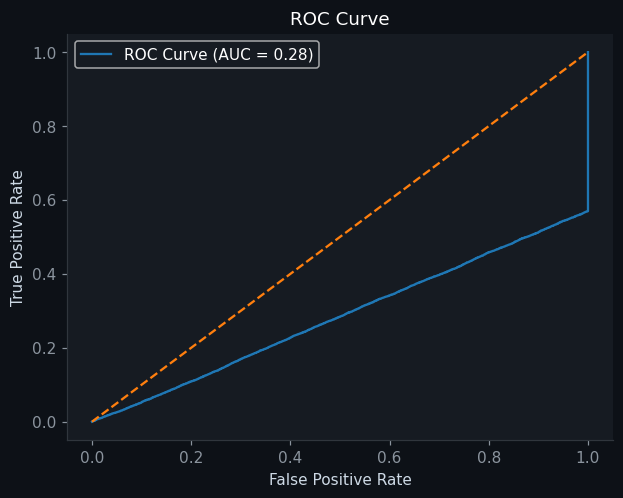

In [27]:
from sklearn.metrics import roc_curve, auc

# Convert target to binary (High Risk = 1, Low Risk = 0)
y_test_binary = (y_test == "High Risk").astype(int)

# Get probability of High Risk
y_prob = model.predict_proba(X_test)[:,1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

# Plot ROC curve
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [28]:
print(model.classes_)

['High Risk' 'Low Risk']


AUC Score: 0.7162938668007052


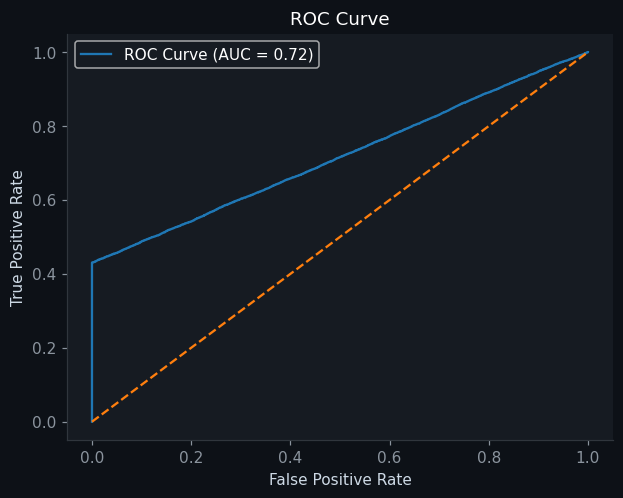

In [30]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert target to binary
y_test_binary = (y_test == "High Risk").astype(int)

# Use correct probability column (High Risk)
y_prob = model.predict_proba(X_test)[:,0]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [31]:
# Extract values from confusion matrix
tn, fp, fn, tp = cm.ravel()

print("True Negatives (Low Risk correctly predicted):", tn)
print("False Positives (Low Risk predicted as High):", fp)
print("False Negatives (High Risk predicted as Low):", fn)
print("True Positives (High Risk correctly predicted):", tp)

True Negatives (Low Risk correctly predicted): 14074
False Positives (Low Risk predicted as High): 6949
False Negatives (High Risk predicted as Low): 8025
True Positives (High Risk correctly predicted): 10956
